<a href="https://colab.research.google.com/github/sw-sys/codebar_capstone_work/blob/main/Capstone_Loans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#load dataset

df = pd.read_csv("pixels_banking_loan_repayment_capstone_dataset.csv")

#print(df.head(10))

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1176 non-null   float64
 2   region                    1187 non-null   object 
 3   account_type              1172 non-null   object 
 4   tenure_months             1200 non-null   int64  
 5   monthly_income            1164 non-null   float64
 6   avg_monthly_balance       1135 non-null   float64
 7   credit_score              1159 non-null   float64
 8   num_products              1200 non-null   int64  
 9   has_credit_card           1169 non-null   object 
 10  has_crypto_wallet         1200 non-null   object 
 11  uses_mobile_app           1175 non-null   object 
 12  customer_service_calls    1200 non-null   int64  
 13  missed_payments_6m        1200 non-null   int64  
 14  support_

In [5]:
data_types_records = []
for column_name in df.columns:
    data_types_records.append({'Column Name': column_name, 'Data Type': str(df[column_name].dtypes)})

column_dtypes_df = pd.DataFrame(data_types_records)

# Sort the DataFrame by 'Data Type' alphabetically
column_dtypes_df_sorted = column_dtypes_df.sort_values(by='Data Type').reset_index(drop=True)

# Custom formatting for display
col_name_data = column_dtypes_df_sorted['Column Name']
dtype_data = column_dtypes_df_sorted['Data Type']

# Calculate maximum width for each column, including header
max_col_name_len = max(len('Column Name'), col_name_data.str.len().max())
max_dtype_len = max(len('Data Type'), dtype_data.str.len().max())

# Print header with specified alignment
print(f"{("Column Name"):<{max_col_name_len}} {('Data Type'):^{max_dtype_len}}")
# Print a separator line for readability
print(f"{'-'*max_col_name_len} {'-'*max_dtype_len}")

# Print data rows with specified alignment
for index, row in column_dtypes_df_sorted.iterrows():
    col_name_val = row['Column Name']
    dtype_val = str(row['Data Type'])
    print(f"{col_name_val:<{max_col_name_len}} {dtype_val:^{max_dtype_len}}")

Column Name              Data Type
------------------------ ---------
age                       float64 
debt_to_income_ratio      float64 
monthly_income            float64 
avg_monthly_balance       float64 
credit_score              float64 
digital_engagement_score  float64 
interest_rate             float64 
support_rating            float64 
monthly_fees              float64 
loan_repaid                int64  
loan_term_months           int64  
tenure_months              int64  
num_products               int64  
loan_amount                int64  
customer_service_calls     int64  
missed_payments_6m         int64  
customer_id               object  
has_crypto_wallet         object  
has_credit_card           object  
account_type              object  
region                    object  
contract_type             object  
uses_mobile_app           object  


In [6]:
df.isnull().sum().sum()

np.int64(478)

In [7]:
df.isnull().sum()

,0
customer_id,0
age,24
region,13
account_type,28
tenure_months,0
monthly_income,36
avg_monthly_balance,65
credit_score,41
num_products,0
has_credit_card,31


In [8]:
missing_df = df.isnull().sum()
mv = missing_df[missing_df > 0].sort_values(ascending=False)
mv_i = mv.reset_index()
mv_i.columns = ['Feature', 'Missing values']

# Custom formatting for display
feature_col_data = mv_i['Feature']
missing_col_data = mv_i['Missing values'].astype(str)

# Calculate maximum width for each column, including header
max_feature_len = max(len('Feature'), feature_col_data.str.len().max())
max_missing_len = max(len('Missing values'), missing_col_data.str.len().max())

# Print header with specified alignment
print(f"{('Feature'):<{max_feature_len}} {('Missing values'):^{max_missing_len}}")
# Print a separator line for readability
print(f"{'-'*max_feature_len} {'-'*max_missing_len}")

# Print data rows with specified alignment
for index, row in mv_i.iterrows():
    feature_val = row['Feature']
    missing_val = str(row['Missing values'])
    print(f"{feature_val:<{max_feature_len}} {missing_val:^{max_missing_len}}")

Feature                  Missing values
------------------------ --------------
digital_engagement_score       71      
avg_monthly_balance            65      
support_rating                 65      
debt_to_income_ratio           43      
credit_score                   41      
interest_rate                  36      
monthly_income                 36      
has_credit_card                31      
account_type                   28      
uses_mobile_app                25      
age                            24      
region                         13      


In [9]:
# missing values as a percentage

missing_perc = (df.isnull().sum() / len(df)) * 100
missing_perc[missing_perc > 0].sort_values(ascending=False)

,0
digital_engagement_score,5.916667
avg_monthly_balance,5.416667
support_rating,5.416667
debt_to_income_ratio,3.583333
credit_score,3.416667
interest_rate,3.000000
monthly_income,3.000000
has_credit_card,2.583333
account_type,2.333333
uses_mobile_app,2.083333


In [10]:
df.columns

Index(['customer_id', 'age', 'region', 'account_type', 'tenure_months',
       'monthly_income', 'avg_monthly_balance', 'credit_score', 'num_products',
       'has_credit_card', 'has_crypto_wallet', 'uses_mobile_app',
       'customer_service_calls', 'missed_payments_6m', 'support_rating',
       'contract_type', 'monthly_fees', 'digital_engagement_score',
       'loan_amount', 'loan_term_months', 'debt_to_income_ratio',
       'interest_rate', 'loan_repaid'],
      dtype='object')

In [11]:
# check if customers ids are unique
dup_customers = df['customer_id'].duplicated().sum()
dup_customers

np.int64(0)

In [12]:
age_min = df['age'].min()
age_max = df['age'].max()

print(f"The minimum age is:", age_min)
print(f"The minimum age is:", age_max)

age_range = age_max - age_min

print(f"The age range size is:", age_range)

The minimum age is: 18.0
The minimum age is: 78.0
The age range size is: 60.0


In [13]:
#count number of 18 year olds
count_18_year_olds = df['age'].value_counts().get(18.0, 0) # Use .get() to handle cases where 18.0 might not be present
print(f"Number of 18-year-olds: {count_18_year_olds}")

# total number of ages in df (non-null values)
total_ages = df['age'].count()
print(f"Total number of non-null ages: {total_ages}")

Number of 18-year-olds: 74
Total number of non-null ages: 1176


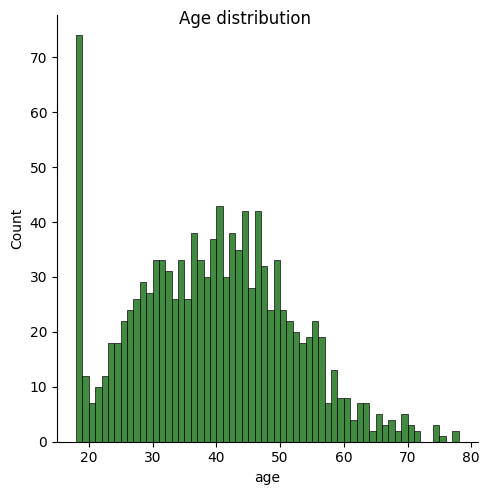

In [14]:
# age based analysis - check the central tendency, spread and skewness

sns.displot(df['age'],
             kde=False,
             color='darkgreen',
             bins=60)
plt.suptitle("Age distribution")
plt.show()

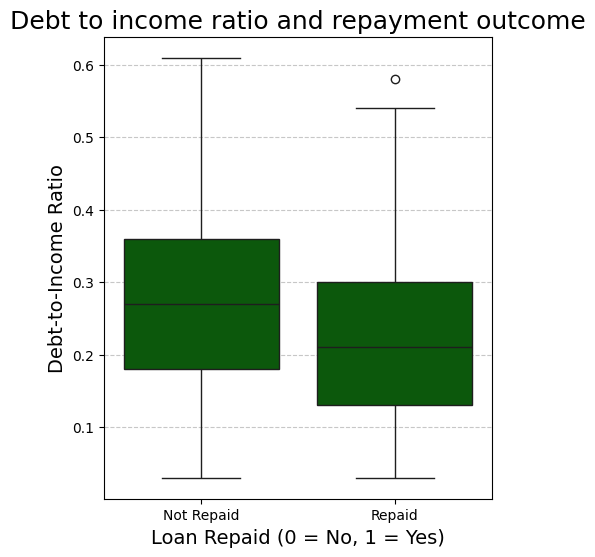

In [25]:
# Debt-to-Income Ratio vs. Loan Repaid

# those with a higher debt-to-income ratio are less likely to repay

plt.figure(figsize=(5, 6))
sns.boxplot(x=df['loan_repaid'], y=df['debt_to_income_ratio'], data=df, color='darkgreen')
plt.title('Debt to income ratio and repayment outcome', fontsize=18)
plt.xlabel('Loan Repaid (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Debt-to-Income Ratio', fontsize=14)
plt.xticks([0, 1], ['Not Repaid', 'Repaid'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
# credit score vs loan repayment
#the higher the credit score, the more likely someone was to repay


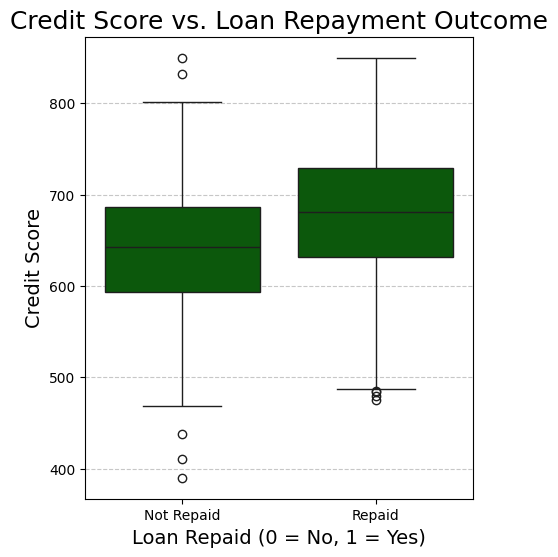

In [26]:
plt.figure(figsize=(5, 6))
sns.boxplot(x=df['loan_repaid'], y=df['credit_score'], data=df, color='darkgreen')
plt.title('Credit Score vs. Loan Repayment Outcome', fontsize=18)
plt.xlabel('Loan Repaid (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Credit Score', fontsize=14)
plt.xticks([0, 1], ['Not Repaid', 'Repaid'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
# loan repayment vs missed_payments_6m

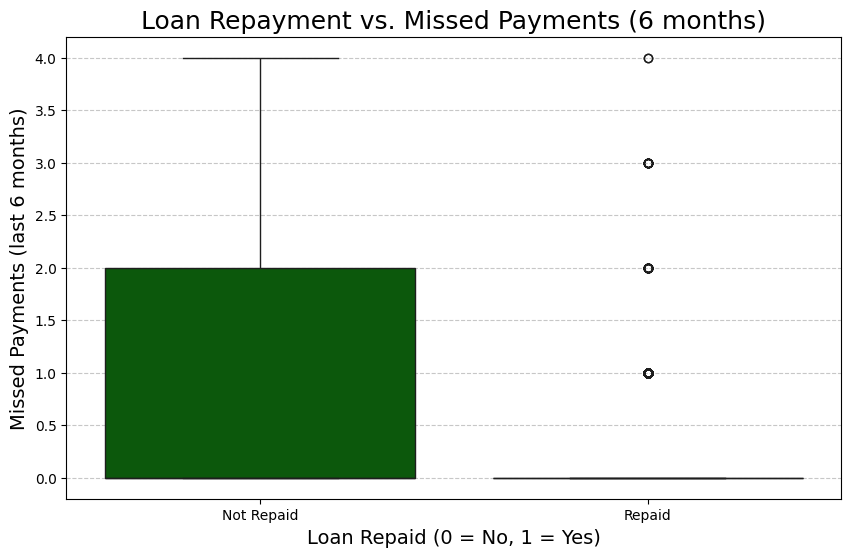

In [27]:
# loan repayment vs missed_payments_6m
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['loan_repaid'], y=df['missed_payments_6m'], data=df, color='darkgreen')
plt.title('Loan Repayment vs. Missed Payments (6 months)', fontsize=18)
plt.xlabel('Loan Repaid (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Missed Payments (last 6 months)', fontsize=14)
plt.xticks([0, 1], ['Not Repaid', 'Repaid'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

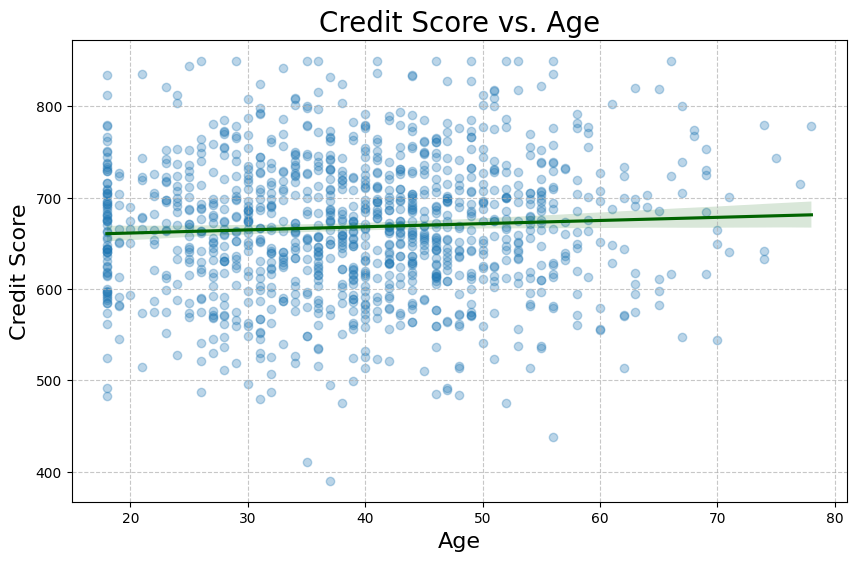

In [30]:
#credit score vs age
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='credit_score', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'darkgreen'})
plt.title('Credit Score vs. Age', fontsize=20)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Credit Score', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

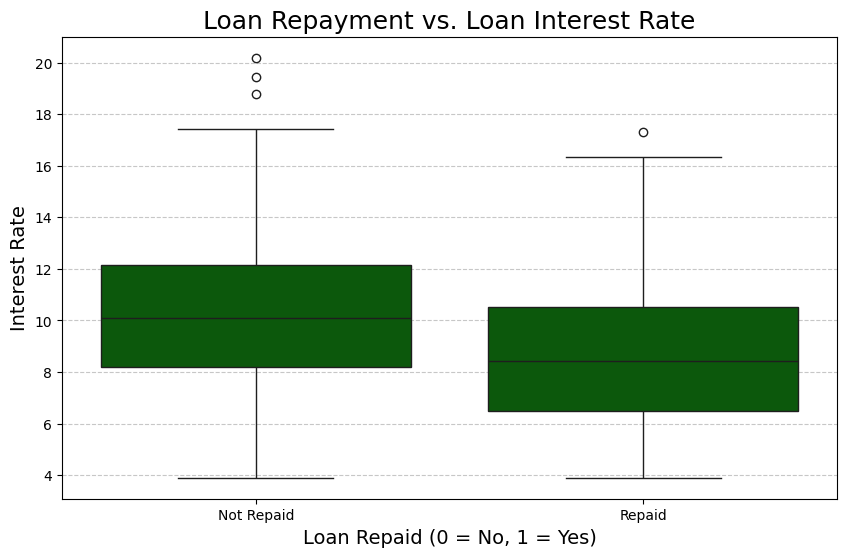

In [31]:
# loan repayment vs loan interest rate
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['loan_repaid'], y=df['interest_rate'], data=df, color='darkgreen')
plt.title('Loan Repayment vs. Loan Interest Rate', fontsize=18)
plt.xlabel('Loan Repaid (0 = No, 1 = Yes)', fontsize=14)
plt.ylabel('Interest Rate', fontsize=14)
plt.xticks([0, 1], ['Not Repaid', 'Repaid'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

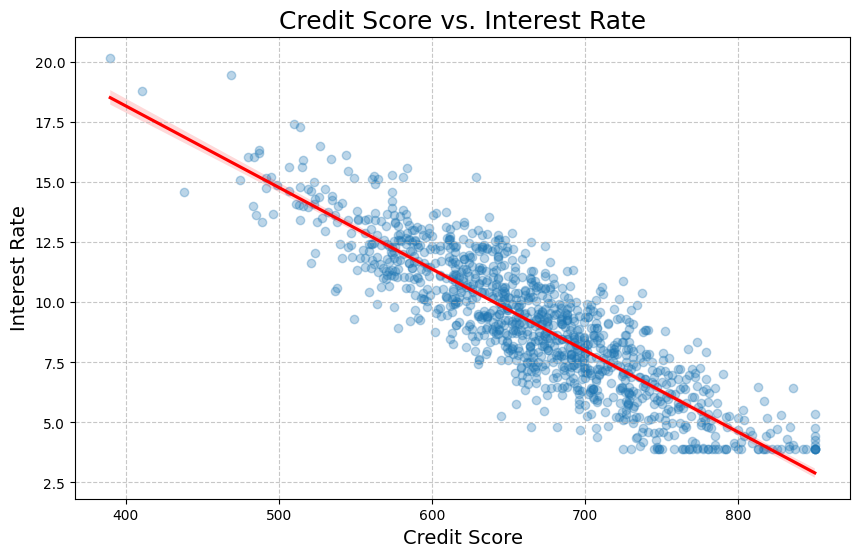

In [32]:
#credit score vs interest rate
plt.figure(figsize=(10, 6))
sns.regplot(x='credit_score', y='interest_rate', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Credit Score vs. Interest Rate', fontsize=18)
plt.xlabel('Credit Score', fontsize=14)
plt.ylabel('Interest Rate', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

EDA after data cleaned

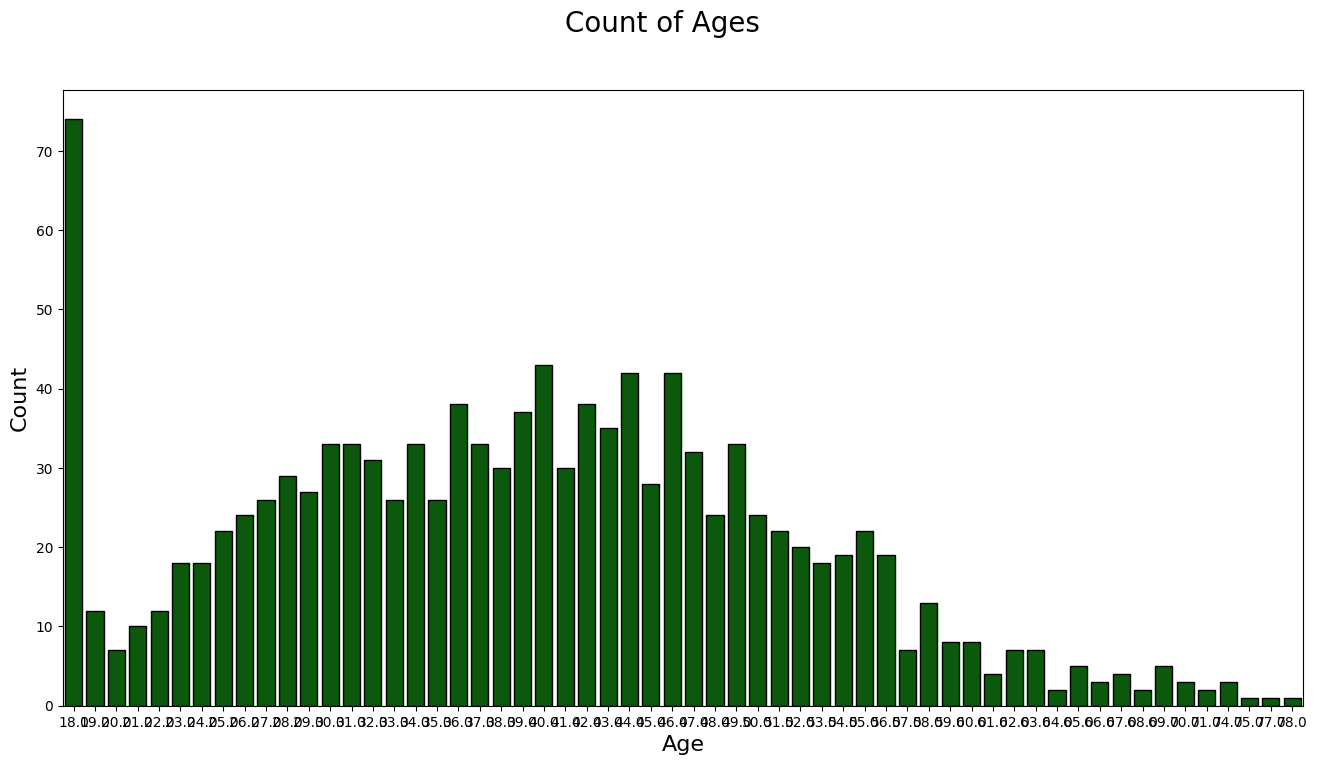

In [22]:
plt.figure(figsize=(16,8))
plt.suptitle("Count of Ages", fontsize=20)

sns.countplot(x=df['age'],
              color='darkgreen',
              edgecolor='black')

plt.xlabel("Age", fontsize=16)
plt.ylabel("Count", fontsize=16)

plt.show()

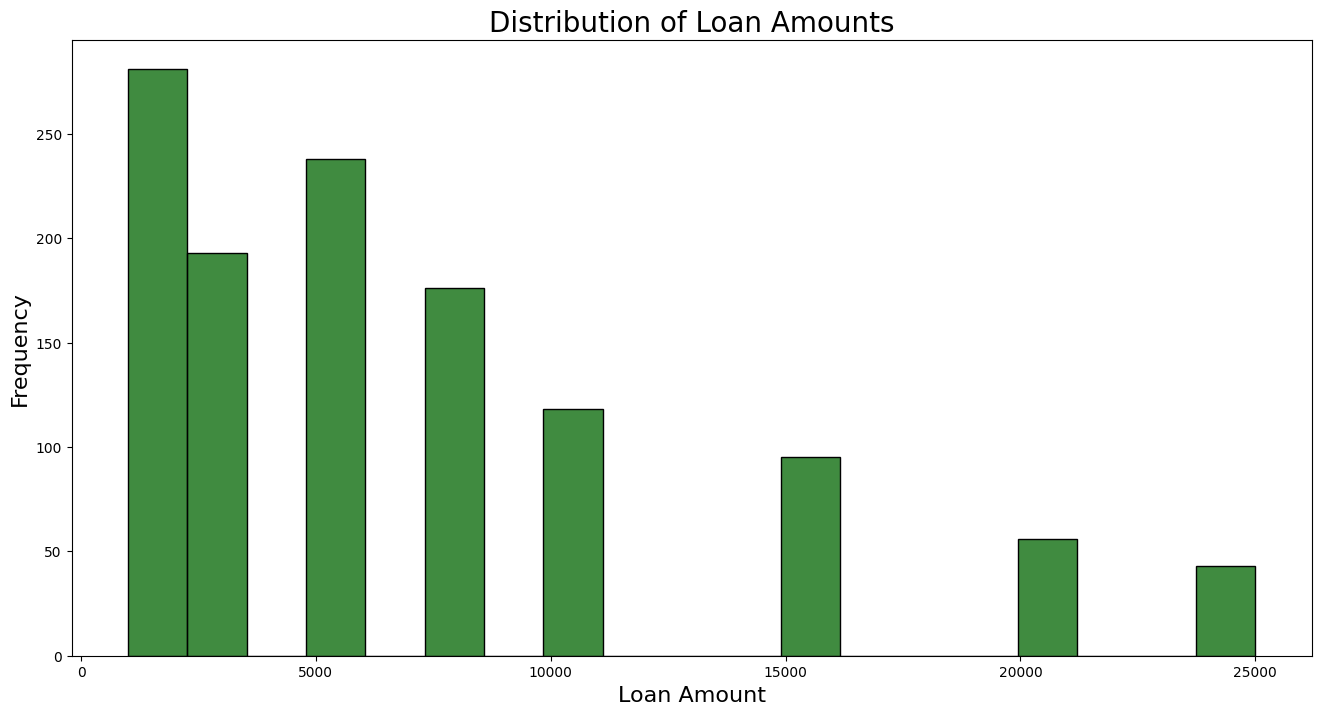

In [23]:
# loan amounts

# the most common amounts =
# decline in loan frequency as size increases

plt.figure(figsize=(16, 8))
sns.histplot(df['loan_amount'], kde=False, color='darkgreen', edgecolor='black')
plt.title('Distribution of Loan Amounts', fontsize=20)
plt.xlabel('Loan Amount', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.show()